In [1]:
import sys
from pathlib import Path
import country_converter as coco
import matplotlib.pyplot as plt
import re
import pandas as pd
import math
import numpy as np
from uncertainties import ufloat, nominal_value, std_dev
from uncertainties.core import CallableStdDev
import plotly.express as px
import pandas as pd

# ---------------------------- Run from Repo Root ----------------------------
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

# ---------------------------- File Paths ----------------------------
main_scale_up_path = BASE_DIR / "results" / "Scale_up_output_MS.csv"
percent_ecw_scale_up_path = BASE_DIR / "results" / "Scale_up_PERCENT_ECW_POLL_MS.csv"

cr_man_scale_up_path = BASE_DIR / "results" / "Scale_up_CR_MAN_MS.csv"
cr_repur_scale_up_path = BASE_DIR / "results" / "Scale_up_CR_REPUR_MS.csv"
cr_stock_scale_up_path = BASE_DIR / "results" / "Scale_up_CR_STOCK.csv"
coalbag_scale_up_path = BASE_DIR / "results" / "Scale_up_COALBAG_MS.csv"

ecw_country = BASE_DIR / "results" / "ECWbyCountry.csv"
ecw_region = BASE_DIR / "results" / "ECWbyRegion.csv"

In [2]:
# ---------- Core Functions ----------
def get_series(df, region):
    row = df.loc[region]
    row = row.iloc[2:]
    time = np.arange(len(row))
    values = np.array([nominal_value(v) for v in row])
    errors = np.array([std_dev(v) for v in row])
    return time, values, errors

def get_ECW(df, region):
    row = df.loc[region]
    ECW_Upper = row[1]
    ECW_Lower = row[0]
    return ECW_Lower, ECW_Upper
    
def plot_region(df, region, ax=None, sigma=1, show_CADR=True, percentage=False, show_start=False, export=False, file_path=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    
    t, vals, errs = get_series(df, region)

    line, = ax.plot(t, vals, label=region, linewidth=2) 
    color = line.get_color()

    ax.fill_between(t, vals - sigma*errs, vals + sigma*errs, color=color, alpha=0.25)

    if show_CADR:
        ecw_lower, ecw_upper = get_ECW(df, region)
        CADR_lower = CADRPP * ecw_lower
        CADR_upper = CADRPP * ecw_upper
        ax.axhspan(CADR_lower, CADR_upper, color=color, alpha=0.12,
                   label=f'Critical Worker Range ({CADR_lower:.2e} - {CADR_upper:.2e})')

    if show_start:
        ax.set_xlim(0,20)
    
    if percentage: 
        ax.set_ylim(0,100)
        ax.set_ylabel("% of Critical Workers Covered", fontsize=10)
    else: 
        ax.set_ylabel("Clean Air Delivery Rate (L/s)", fontsize=10)

    ax.set_xlabel("Weeks", fontsize=10)
    ax.set_title(f"{region} Scale-Up with ±{sigma}σ Bands", fontsize=12, fontweight='bold')

    ax.grid(True, linestyle='--', alpha=0.4)

    ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=4, frameon=True, framealpha=0.9)    
    plt.tight_layout()

    if export and file_path is not None:
        file_path = Path(file_path)
        fig.savefig(file_path, dpi=300, bbox_inches='tight')

    return ax

def plot_multiple_regions(df, region, sigma=1, show_CADR=True,percentage = False, show_start = False, export=False, file_path = None):
    fig, ax = plt.subplots(figsize=(12,8))
    for c in region:
        plot_region(df, c, ax=ax, sigma=sigma, show_CADR = show_CADR, percentage=percentage, show_start=show_start)
    if len(region)>5:
        plt.title(f"Multiple Regions series with ±{sigma}σ bands", fontsize=12, fontweight='bold')
    else:
        region_str = ", ".join(region)
        plt.title(f"{region_str} series with ±{sigma}σ bands", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    if export and file_path is not None:
        file_path = Path(file_path)
        fig.savefig(file_path, dpi=300, bbox_inches='tight')

def plot_stacked_regions(df1, df2, df3, df4, region, ax=None,show_CADR=True,percentage = False, show_start = False, export=False, file_path = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    t1, vals1, _ = get_series(df1, region)
    t2, vals2, _ = get_series(df2, region)
    t3, vals3, _ = get_series(df3, region)
    t4, vals4, _ = get_series(df4, region)
    
    t = t1
    
    if show_CADR:
        ecw_lower, ecw_upper = get_ECW(df1, region)
        CADR_lower = CADRPP * ecw_lower
        CADR_upper = CADRPP * ecw_upper
        ax.axhspan(CADR_lower, CADR_upper, alpha=0.15, 
                   label=f'Critical Worker Range ({CADR_lower:.2e} - {CADR_upper:.2e})')
    
    if percentage: 
        ax.set_ylim(0,100)
        ax.set_ylabel("% of Critical Workers Covered", fontsize=10)
    else: 
        ax.set_ylabel("Clean Air Delivery Rate: L/s", fontsize = 10)

    if show_start:
        max_value = vals1[21]+vals2[21]+vals3[21]+vals4[21]
        ax.set_xlim(0,20)
        ax.set_ylim(0,max_value)

    stack_vals = [vals1, vals2, vals3, vals4]
    
    labels = ['CR Box Repurposing', 'CR Box Stock', 'Coal Baghouse','CR Box Manufacturing']
    
    ax.stackplot(t, *stack_vals, labels=labels, alpha=0.6)
    
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_title(f"{region} - Stacked Area Chart",fontweight='bold')
    ax.set_xlabel("Weeks", fontsize=10)
    ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=4, frameon=True, framealpha=0.9)    
    plt.tight_layout()

    if export and file_path is not None:
        file_path = Path(file_path)
        fig.savefig(file_path, dpi=300, bbox_inches='tight')
   
    return ax

In [3]:
## ---------------------------- Varaibles ---------------------------- 

CADRPP = 100 # L/s
UNRegion_list = ['Australia and New Zealand',
 'Caribbean',
 'Central America',
 'Central Asia',
 'Eastern Africa',
 'Eastern Asia',
 'Eastern Europe',
 'Melanesia',
 'Micronesia',
 'Middle Africa',
 'Northern Africa',
 'Northern America',
 'Northern Europe',
 'Polynesia',
 'South America',
 'South-eastern Asia',
 'Southern Africa',
 'Southern Asia',
 'Southern Europe',
 'Western Africa',
 'Western Asia',
 'Western Europe']

In [4]:
## ---------------------------- Scale Up Plotting for Tester ---------------------------- 
df_MAIN_loaded = pd.read_pickle(main_scale_up_path.with_suffix(".pkl"))
df_PERCENT_ECW_LOADED = pd.read_pickle(percent_ecw_scale_up_path.with_suffix(".pkl"))

df_CR_REPUR_loaded = pd.read_pickle(cr_repur_scale_up_path.with_suffix(".pkl"))
df_CR_STOCK_loaded = pd.read_pickle(cr_stock_scale_up_path.with_suffix(".pkl"))
df_COALBAG_loaded = pd.read_pickle(coalbag_scale_up_path.with_suffix(".pkl"))
df_CR_MAN_loaded = pd.read_pickle(cr_man_scale_up_path.with_suffix(".pkl"))

<Axes: title={'center': 'Global - Stacked Area Chart'}, xlabel='Weeks', ylabel='Clean Air Delivery Rate: L/s'>

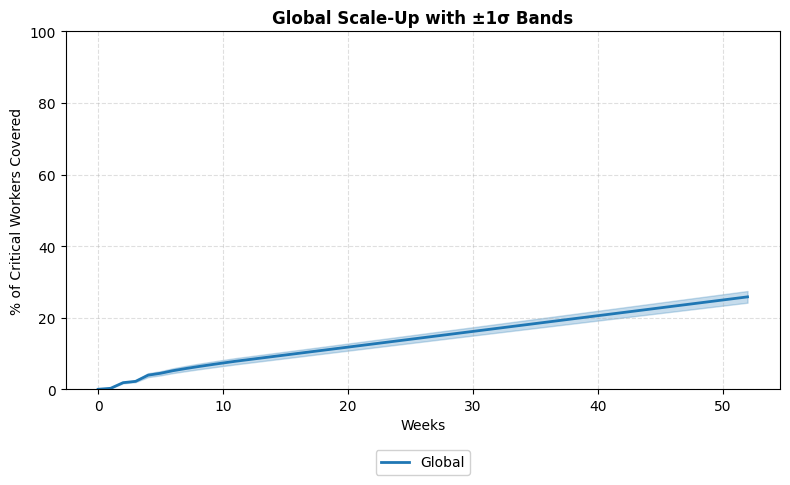

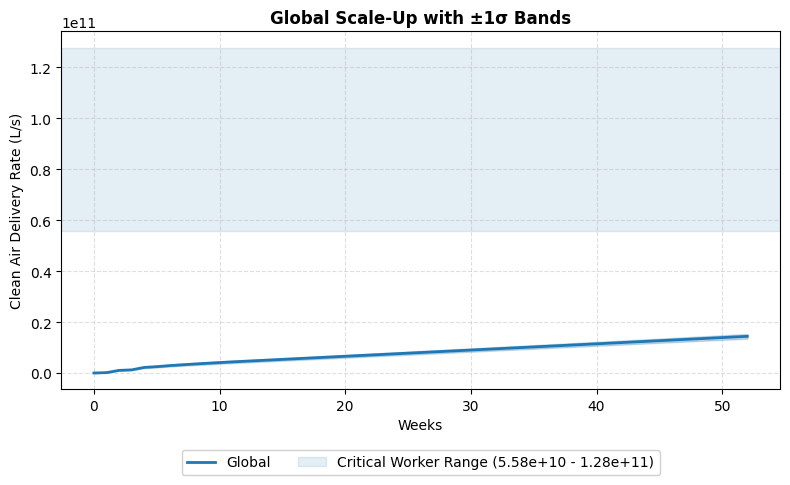

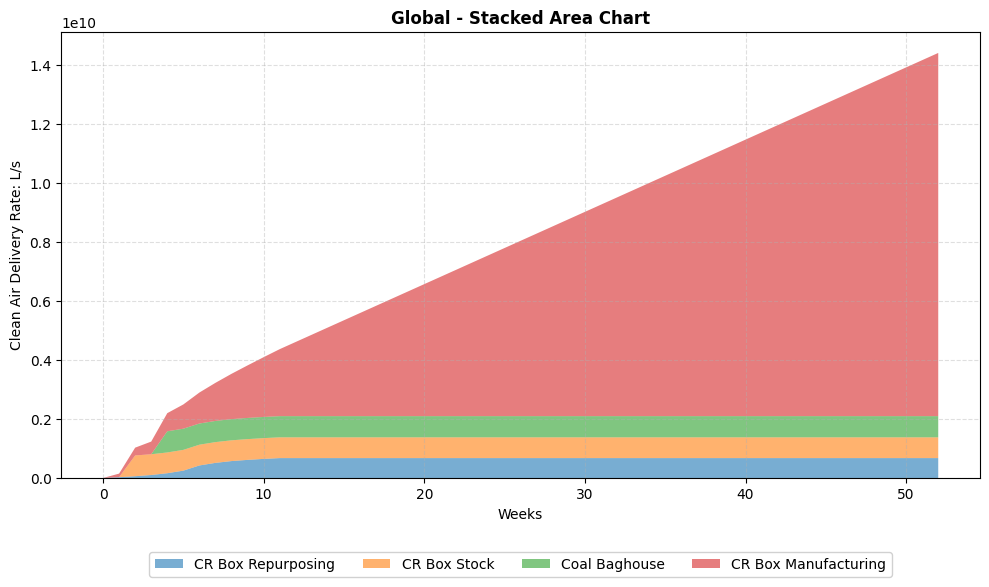

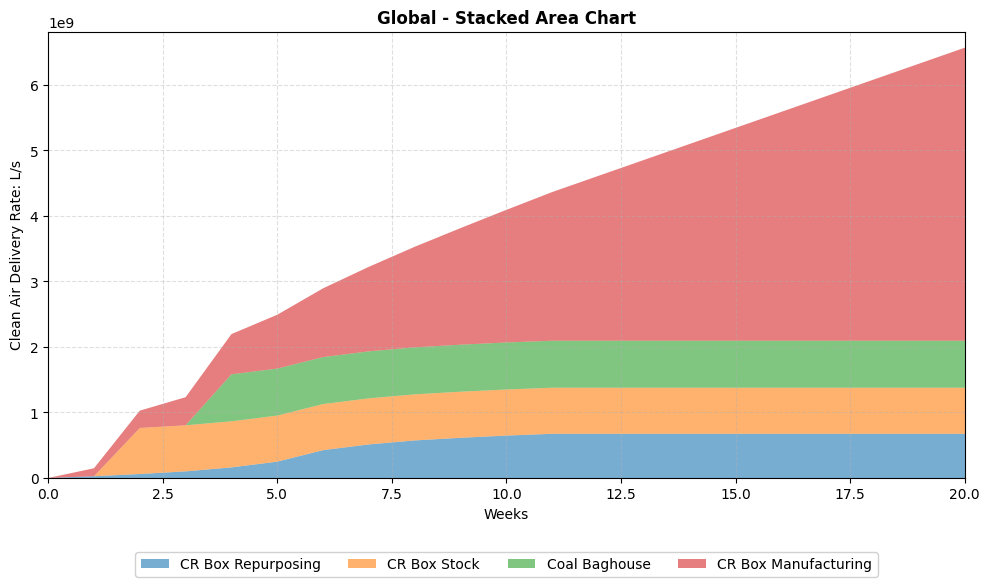

In [5]:
# ---------- Global ----------
output_image_folder = BASE_DIR / "results" / "Output Images" / "Global" / 'Global - Percent ECW'
plot_region(df_PERCENT_ECW_LOADED, 'Global', show_CADR=False, percentage=True, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Global" / 'Global - with CADR Bands'
plot_region(df_MAIN_loaded, 'Global', show_CADR=True, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Global" / 'Global - Stacked'
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Global', show_CADR = False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Global" / 'Global - Stacked Close'
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Global', show_start=True ,show_CADR = False, export=True, file_path=output_image_folder)

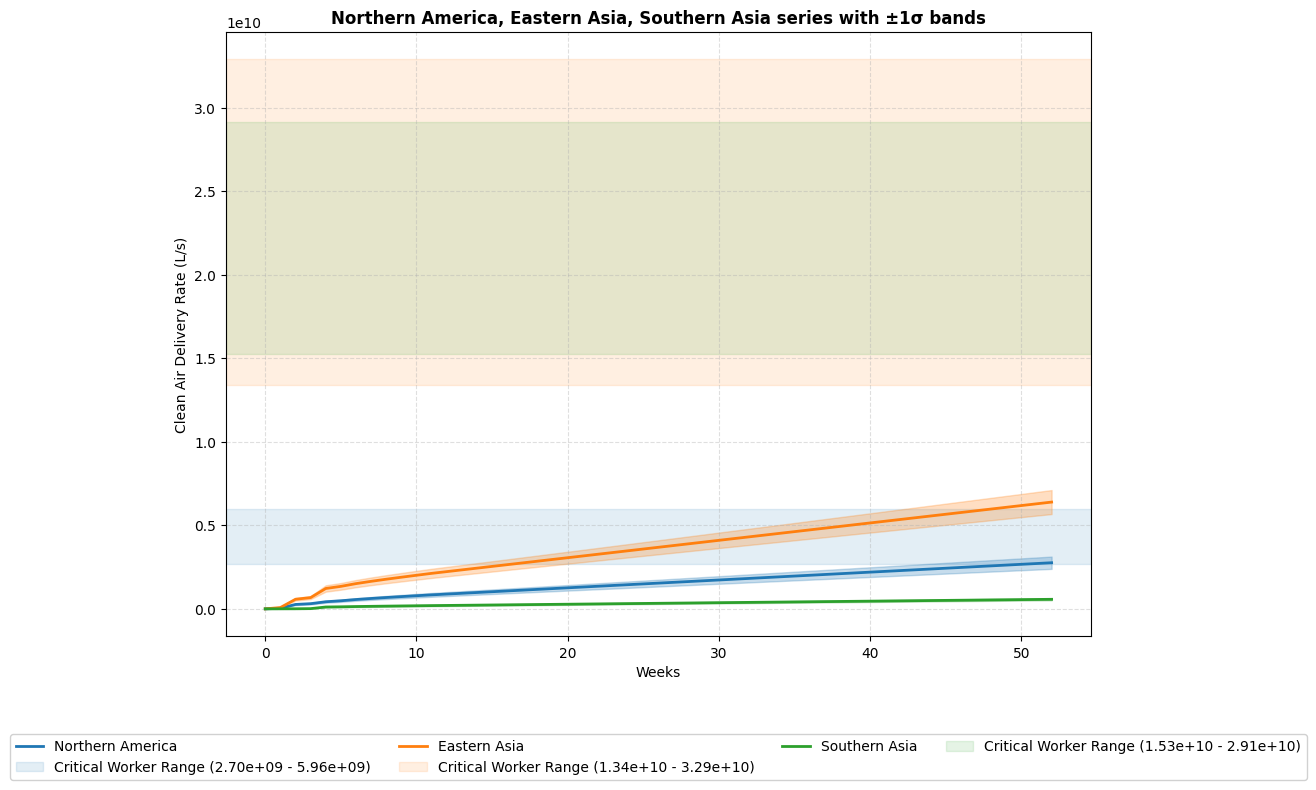

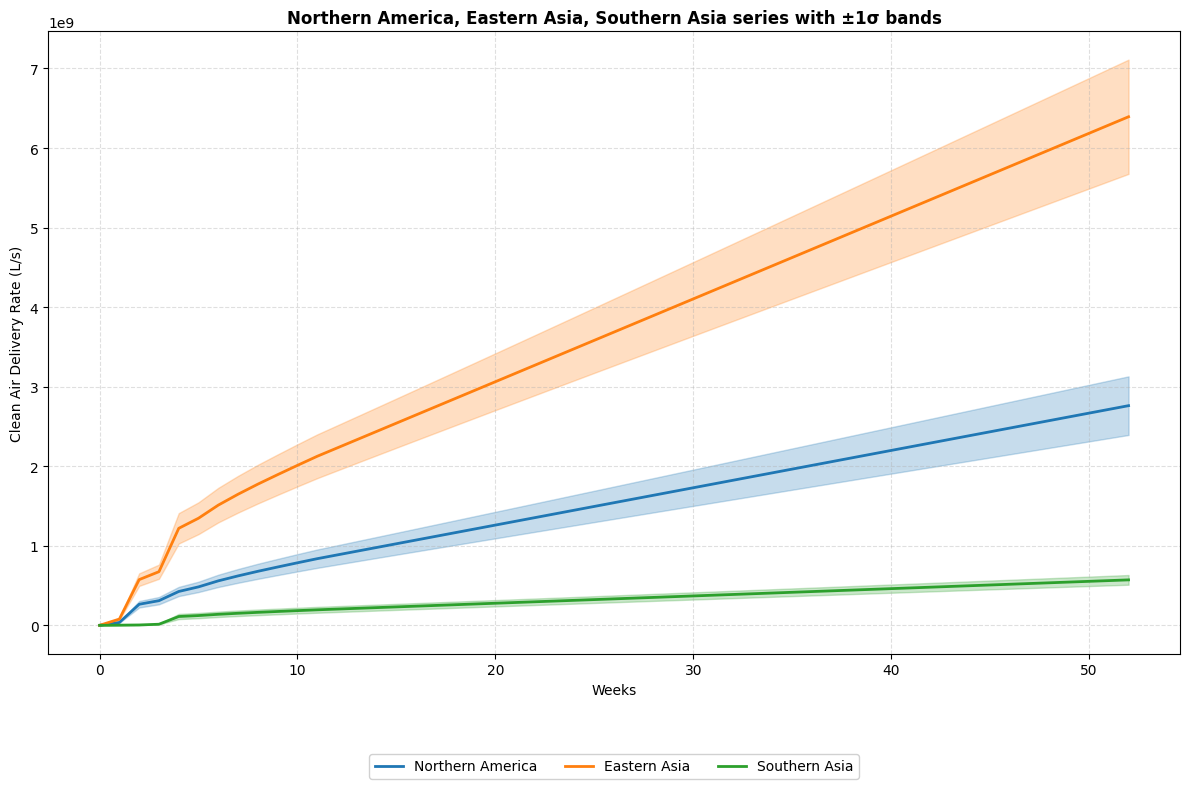

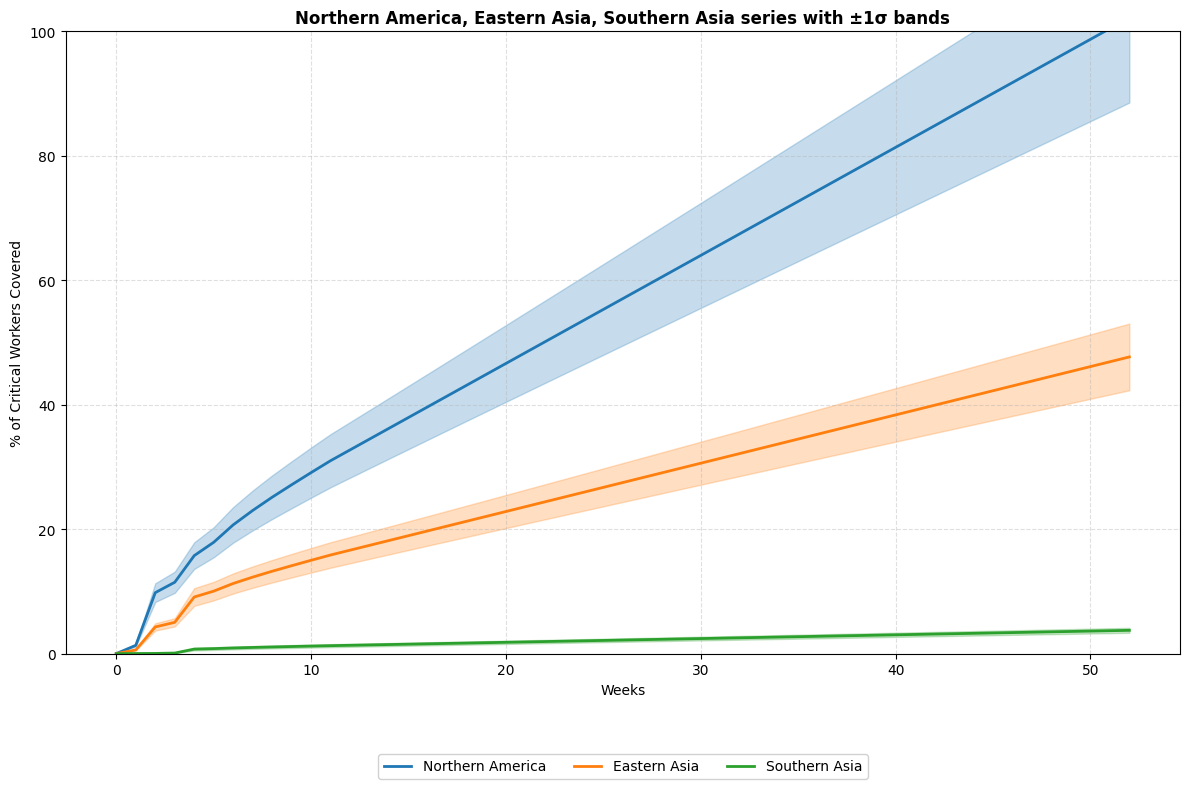

In [6]:
# ---------- Comparisons ----------
output_image_folder = BASE_DIR / "results" / "Output Images" / "Region Comparisons" / 'Region Comparison - with CADR Bands '
plot_multiple_regions(df_MAIN_loaded, ['Northern America','Eastern Asia', 'Southern Asia'],show_CADR=True, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Region Comparisons" / 'Region Comparison - without CADR Bands '
plot_multiple_regions(df_MAIN_loaded, ['Northern America','Eastern Asia', 'Southern Asia'],show_CADR=False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Region Comparisons" / 'Region Comparison - Percent ECW '
plot_multiple_regions(df_PERCENT_ECW_LOADED, ['Northern America','Eastern Asia', 'Southern Asia'],show_CADR=False, percentage=True, export=True, file_path=output_image_folder)

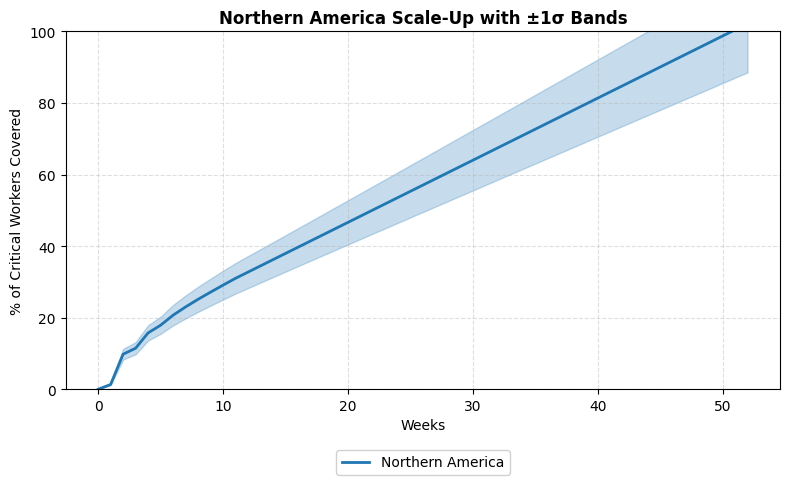

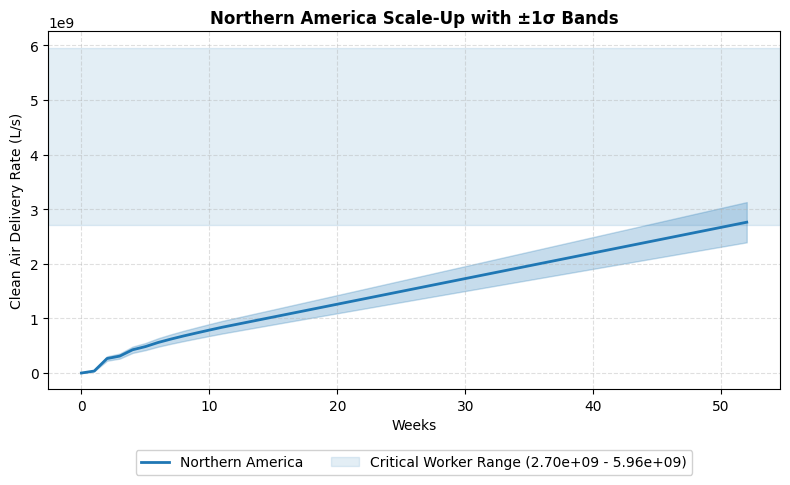

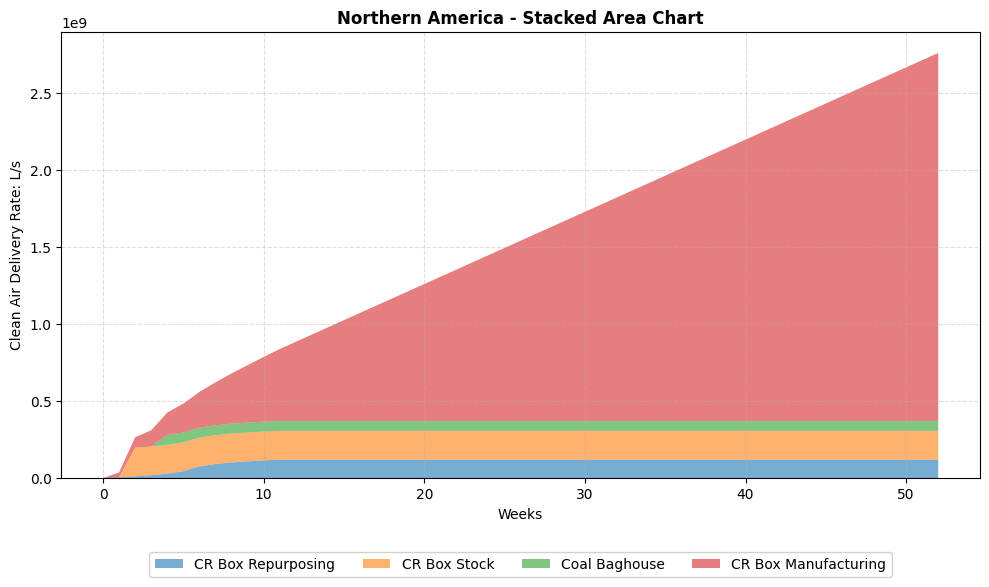

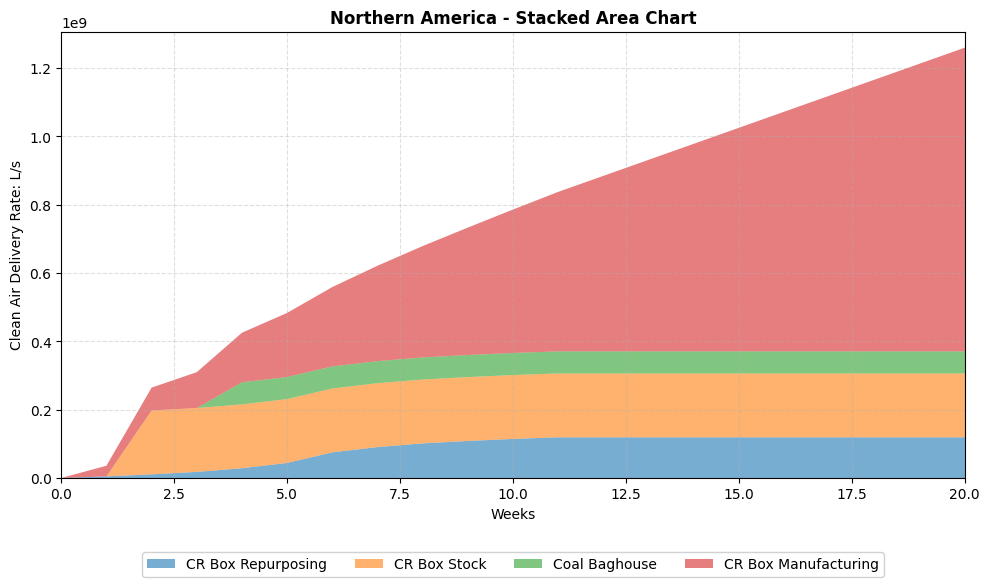

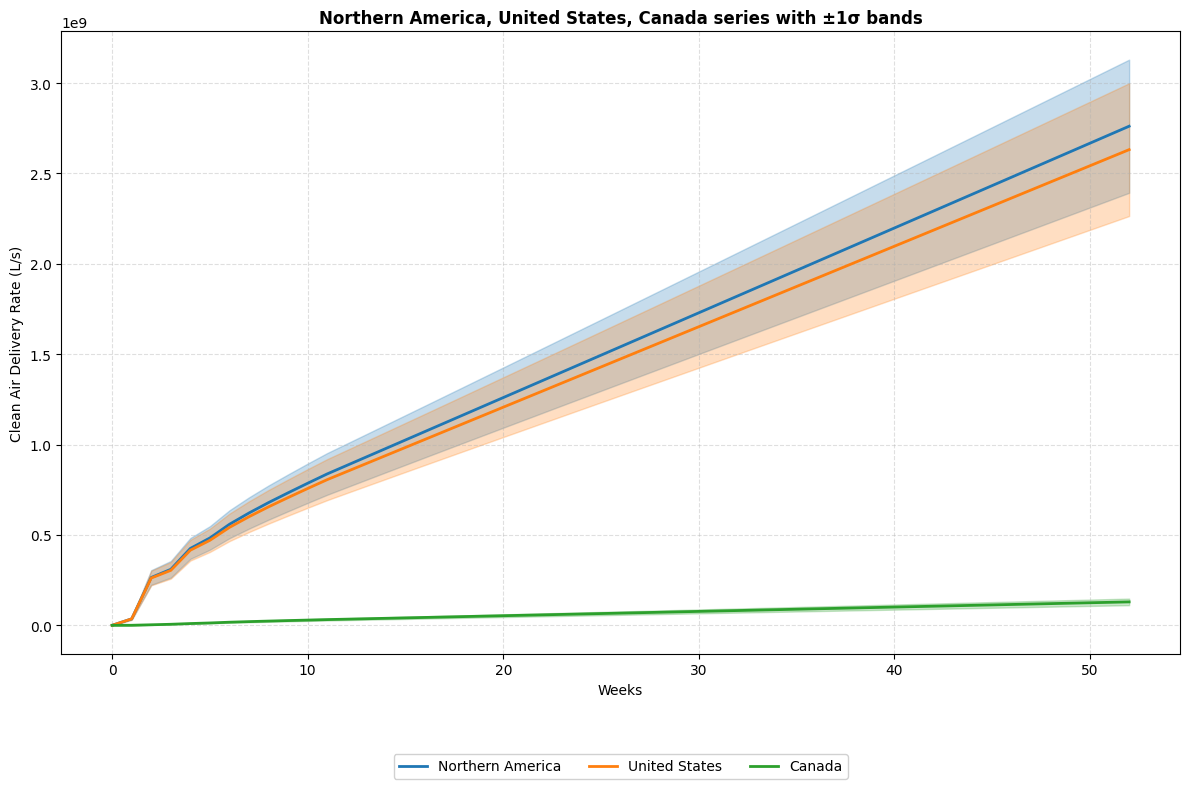

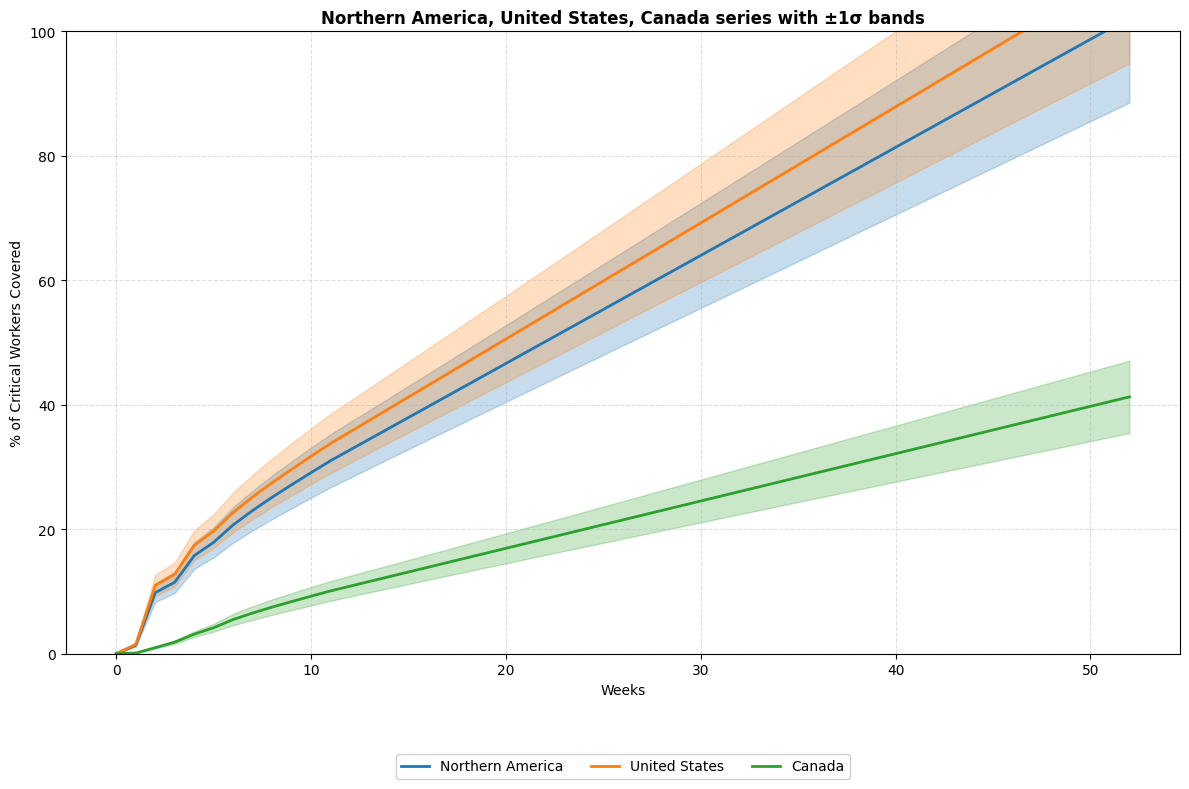

In [7]:
# ---------- Good Scale Up Scenario - Northern America ----------
output_image_folder = BASE_DIR / "results" / "Output Images" / "Northern America" / 'Northern America - Percent ECW'
plot_region(df_PERCENT_ECW_LOADED, 'Northern America', percentage = True, show_CADR = False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Northern America" / 'Northern America - with CADR Bands'
plot_region(df_MAIN_loaded, 'Northern America' ,show_CADR=True, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Northern America" / 'Northern America - Stacked'
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Northern America', show_CADR=False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Northern America" / 'Northern America - Stacked Close'
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Northern America', show_CADR=False, show_start=True, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Northern America" / 'Northern America - Countries breakdown'
plot_multiple_regions(df_MAIN_loaded, ['Northern America','United States', 'Canada'], show_CADR=False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Northern America" / 'Northern America - Countries Percentage breakdown'
plot_multiple_regions(df_PERCENT_ECW_LOADED, ['Northern America','United States', 'Canada'], percentage=True ,show_CADR=False, export=True, file_path=output_image_folder)

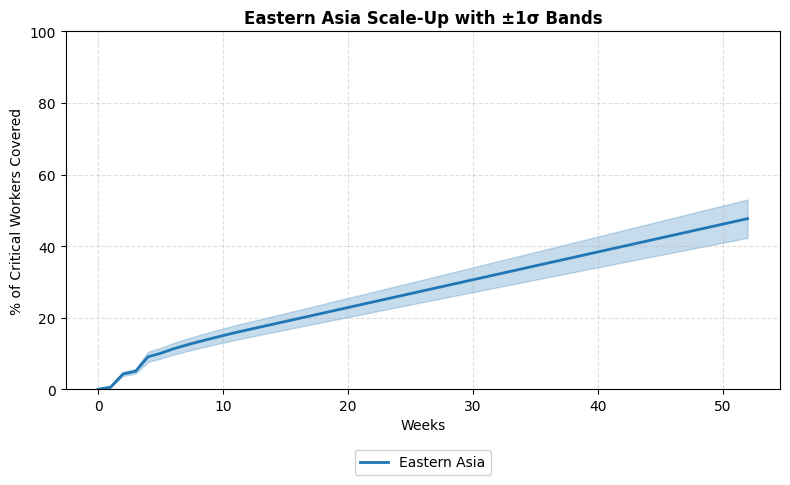

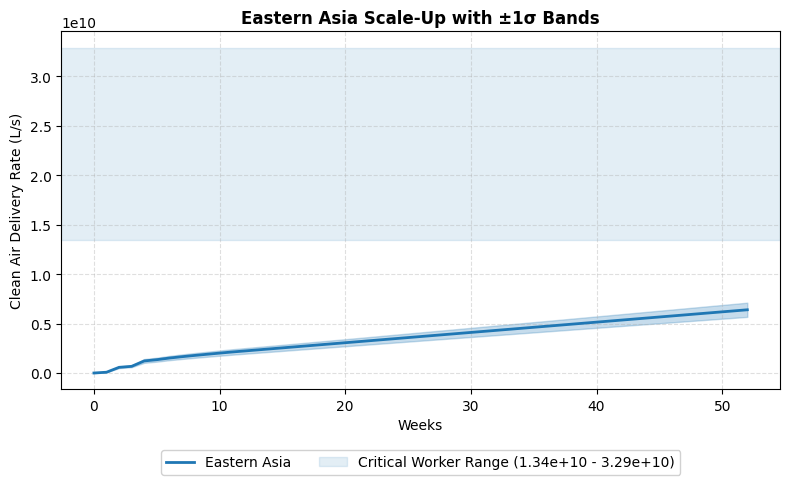

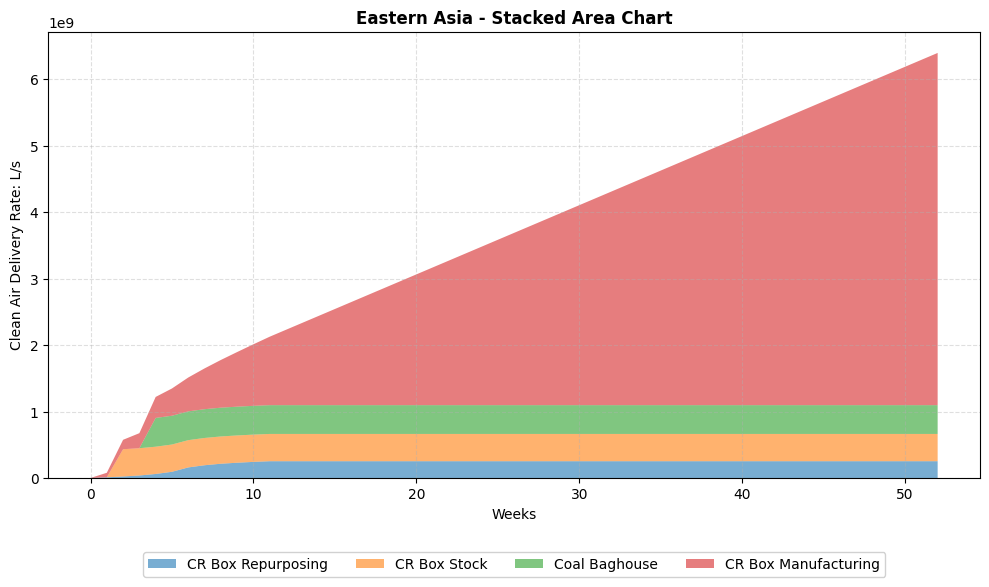

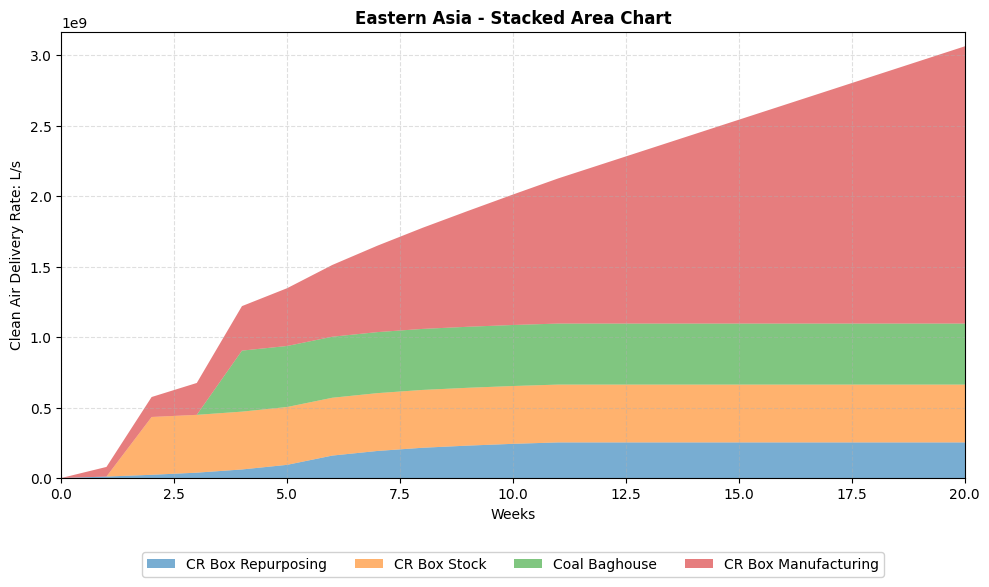

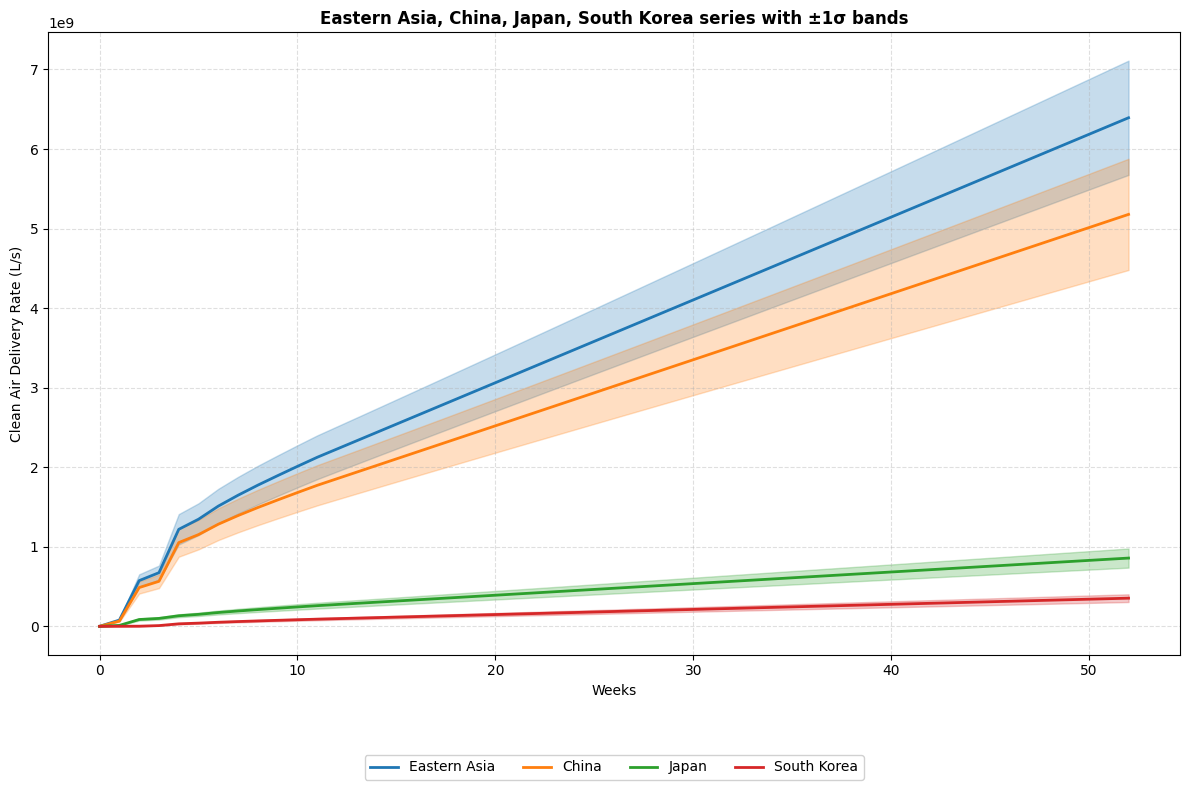

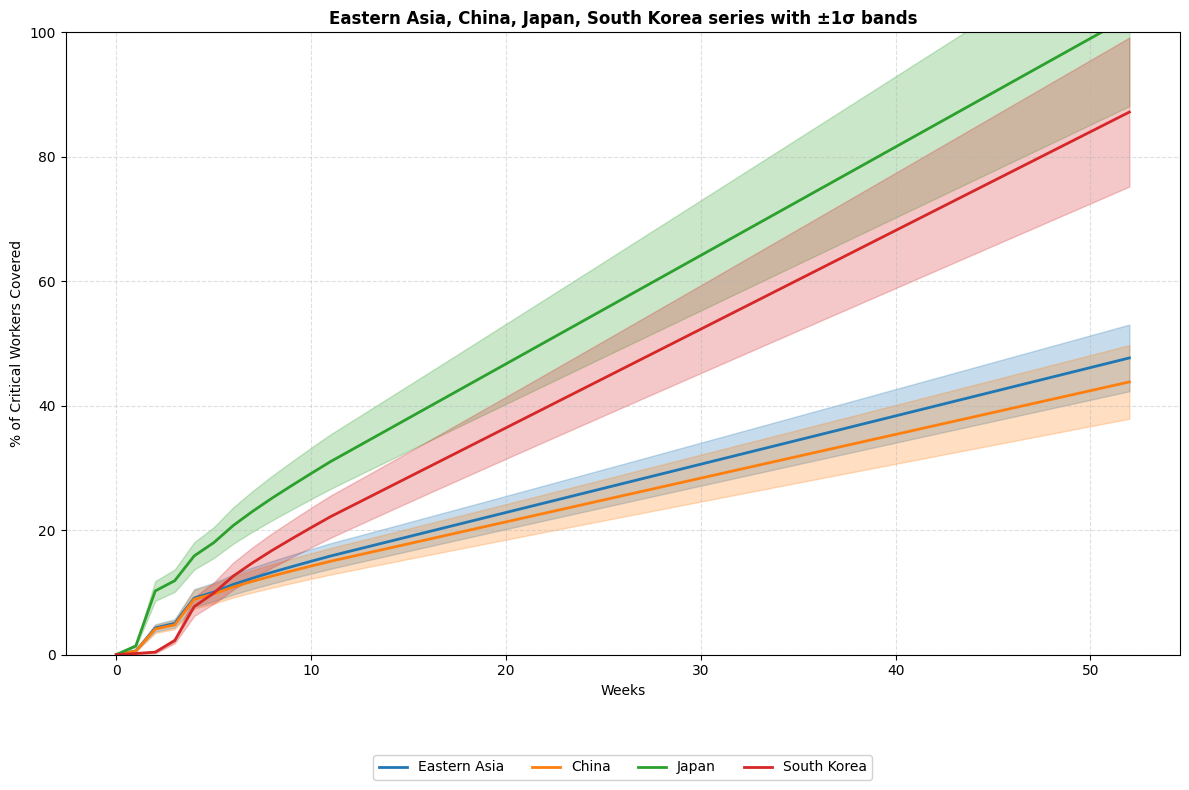

In [8]:
# ---------- Mid Scale Up Scenario - Eastern Asia ----------
output_image_folder = BASE_DIR / "results" / "Output Images" / "Eastern Asia" / 'Eastern Asia - Percent ECW'
plot_region(df_PERCENT_ECW_LOADED, 'Eastern Asia', percentage = True, show_CADR = False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Eastern Asia" / 'Eastern Asia - with CADR Bands'
plot_region(df_MAIN_loaded, 'Eastern Asia' ,show_CADR=True, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Eastern Asia" / 'Eastern Asia - Stacked'
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Eastern Asia', show_CADR=False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Eastern Asia" / 'Eastern Asia - Stacked Close'
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Eastern Asia', show_CADR=False, show_start=True, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Eastern Asia" / 'Eastern Asia - Countries breakdown'
plot_multiple_regions(df_MAIN_loaded, ['Eastern Asia','China', 'Japan', 'South Korea'], show_CADR=False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Eastern Asia" / 'Eastern Asia - Countries Percentage breakdown'
plot_multiple_regions(df_PERCENT_ECW_LOADED, ['Eastern Asia','China', 'Japan', 'South Korea'], percentage=True ,show_CADR=False, export=True, file_path=output_image_folder)

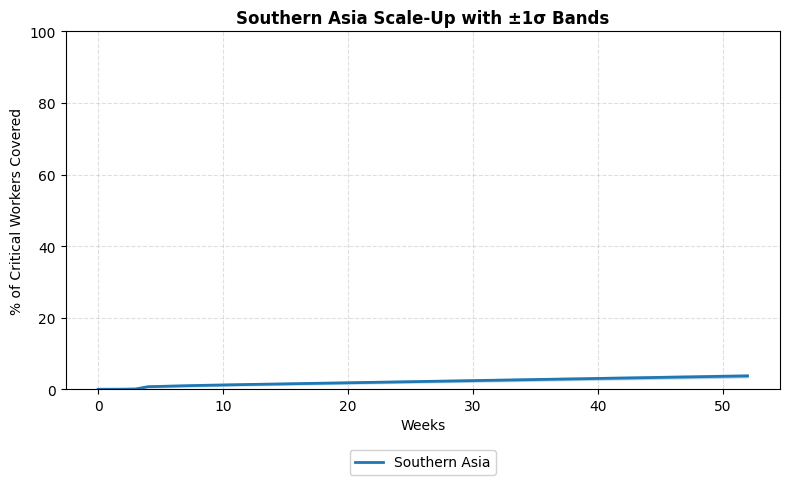

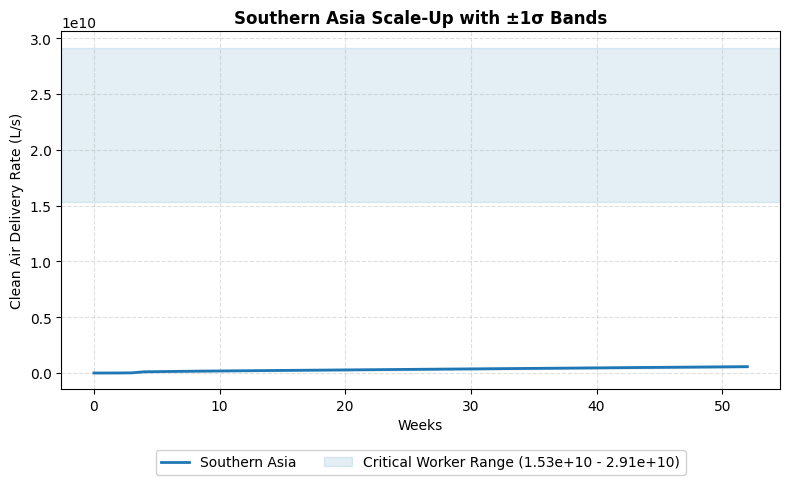

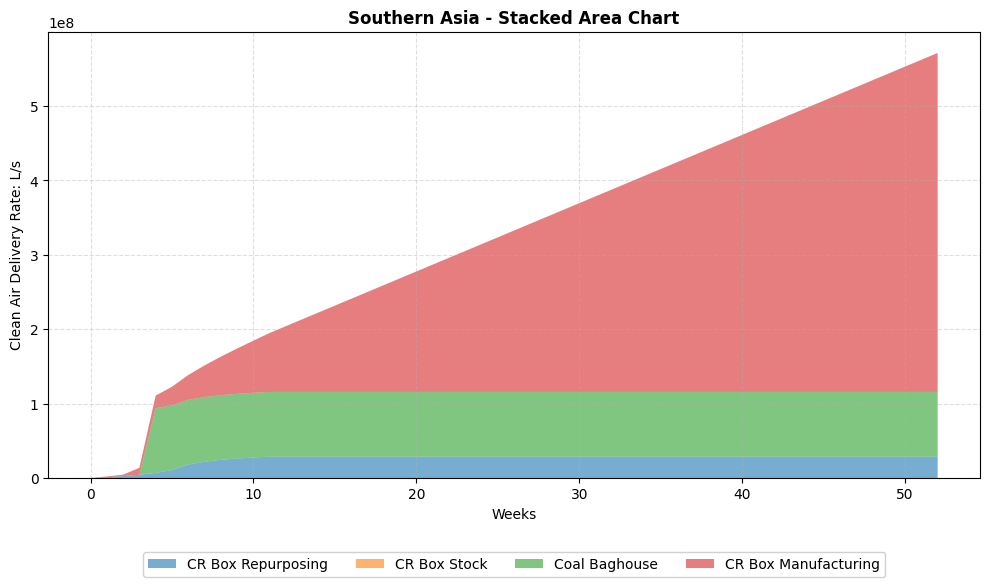

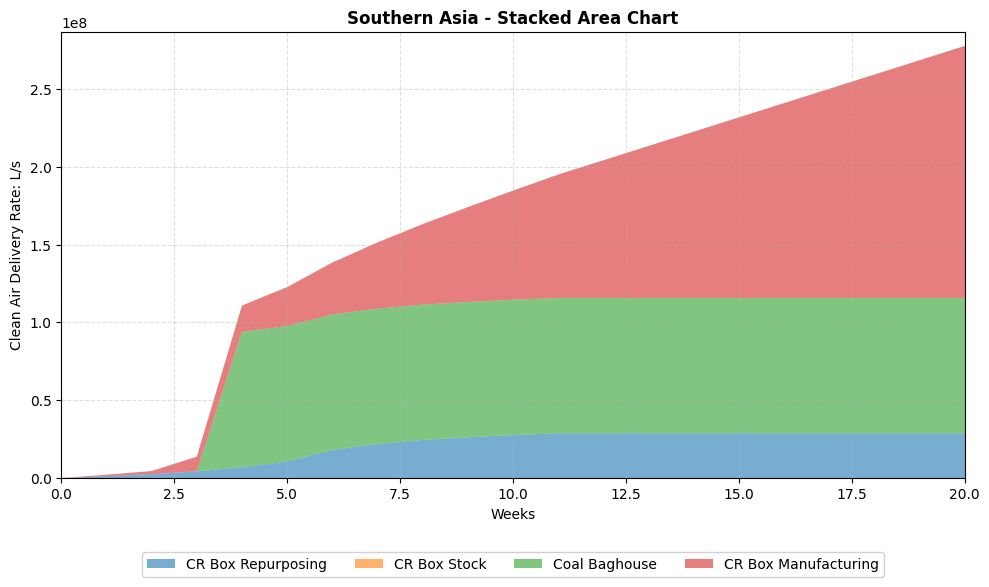

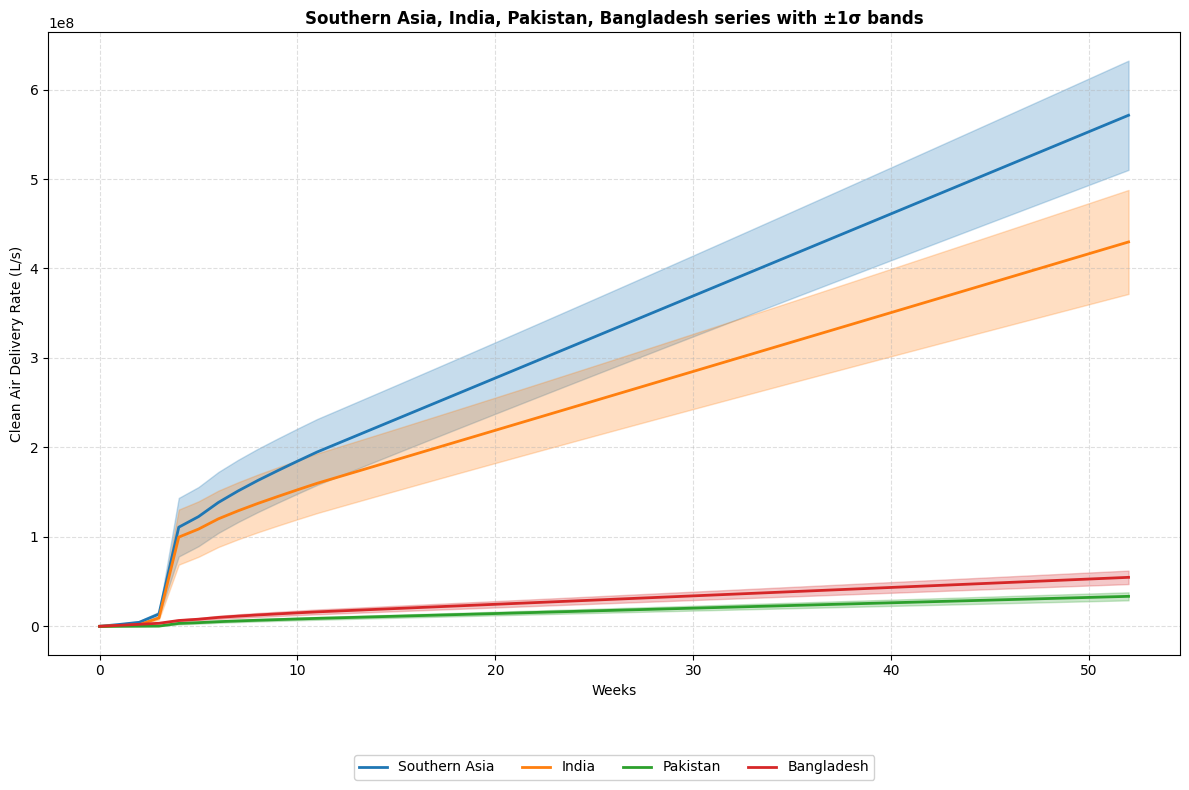

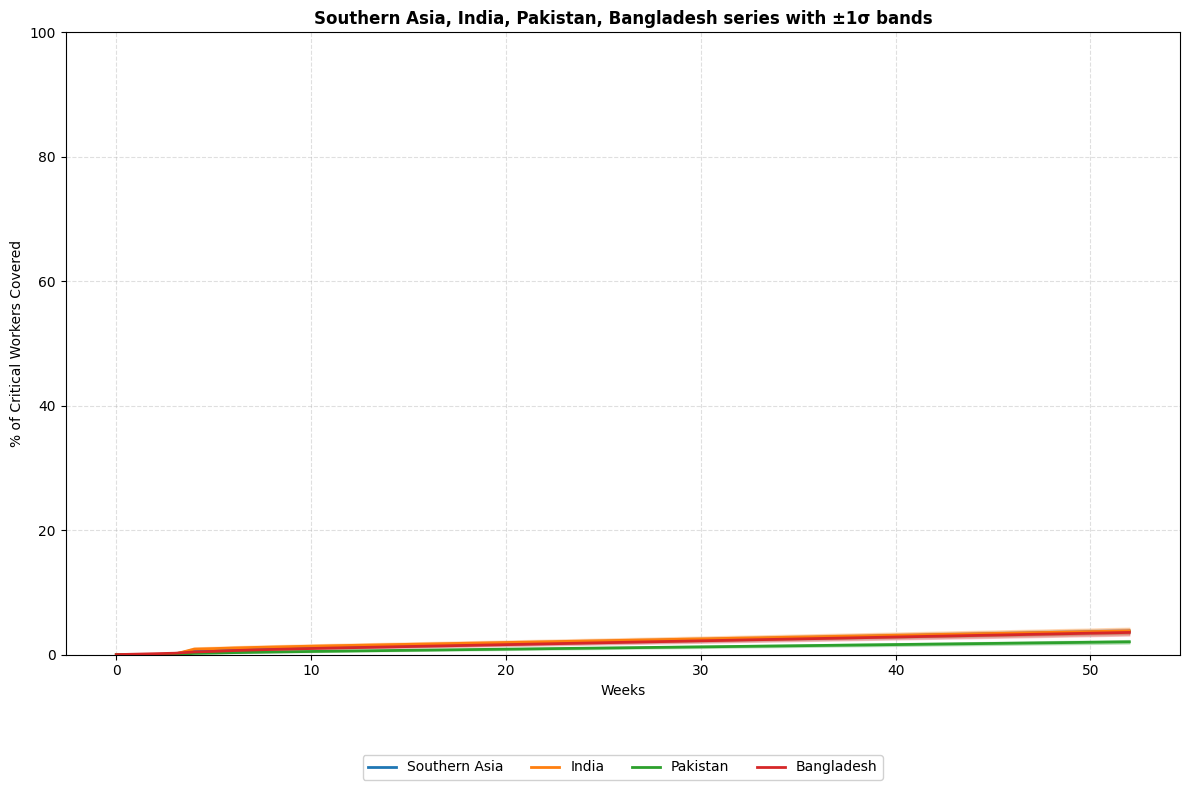

In [9]:
# ---------- Bad Scale Up Scenario - Southern Asia ----------
output_image_folder = BASE_DIR / "results" / "Output Images" / "Southern Asia" / 'Southern Asia - Percent ECW'
plot_region(df_PERCENT_ECW_LOADED, 'Southern Asia', percentage = True, show_CADR = False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Southern Asia" / 'Southern Asia - with CADR Bands'
plot_region(df_MAIN_loaded, 'Southern Asia' ,show_CADR=True, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Southern Asia" / 'Southern Asia - Stacked'
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Southern Asia', show_CADR=False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Southern Asia" / 'Southern Asia - Stacked Close'
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, 'Southern Asia', show_CADR=False, show_start=True, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Southern Asia" / 'Southern Asia - Countries breakdown'
plot_multiple_regions(df_MAIN_loaded, ['Southern Asia','India', 'Pakistan', 'Bangladesh'], show_CADR=False, export=True, file_path=output_image_folder)
output_image_folder = BASE_DIR / "results" / "Output Images" / "Southern Asia" / 'Southern Asia - Countries Percentage breakdown'
plot_multiple_regions(df_PERCENT_ECW_LOADED, ['Southern Asia','India', 'Pakistan', 'Bangladesh'], percentage=True ,show_CADR=False, export=True, file_path=output_image_folder)

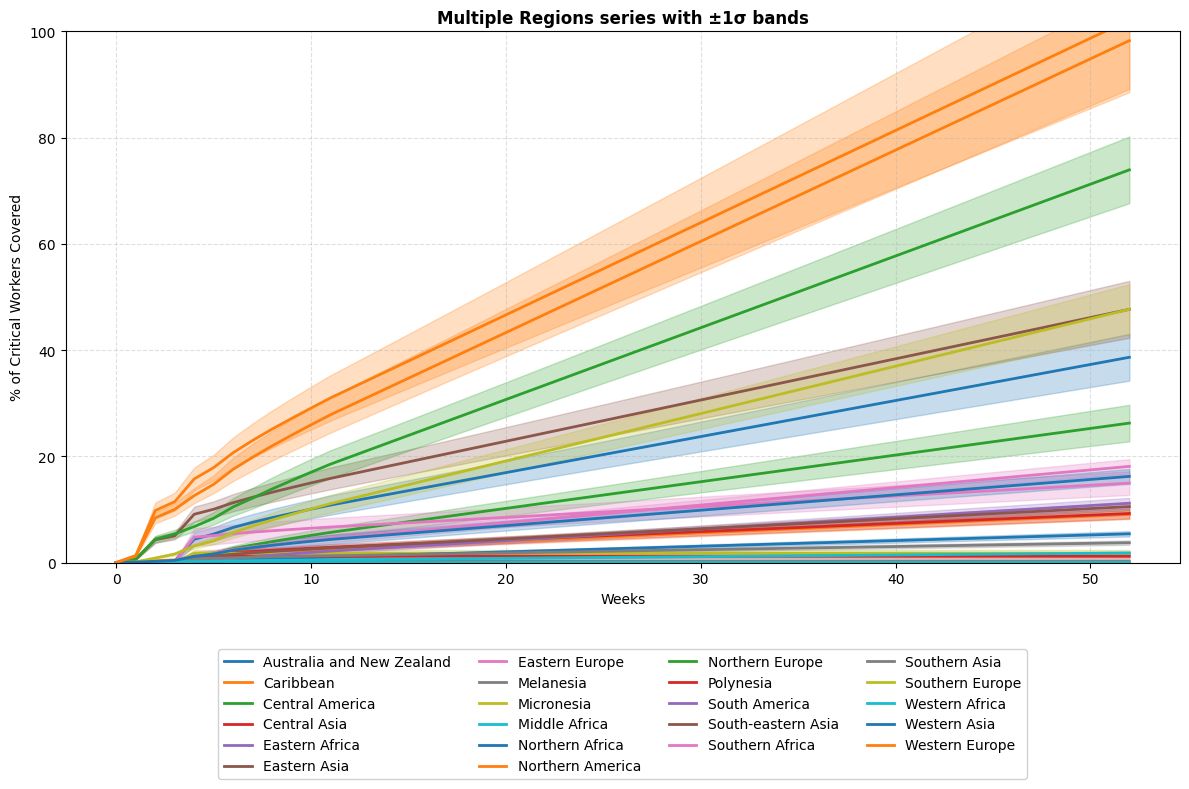

/var/folders/88/_nj8y4k52n30mnjxk6nl86y80000gn/T/ipykernel_65174/3639635903.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8,5))


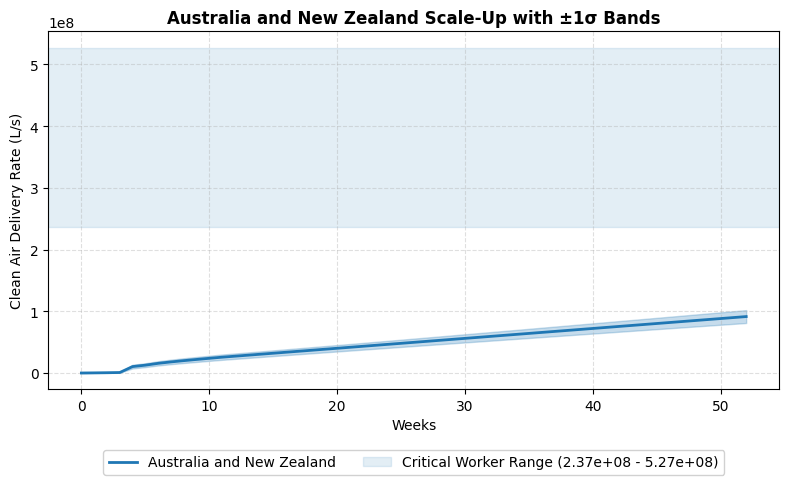

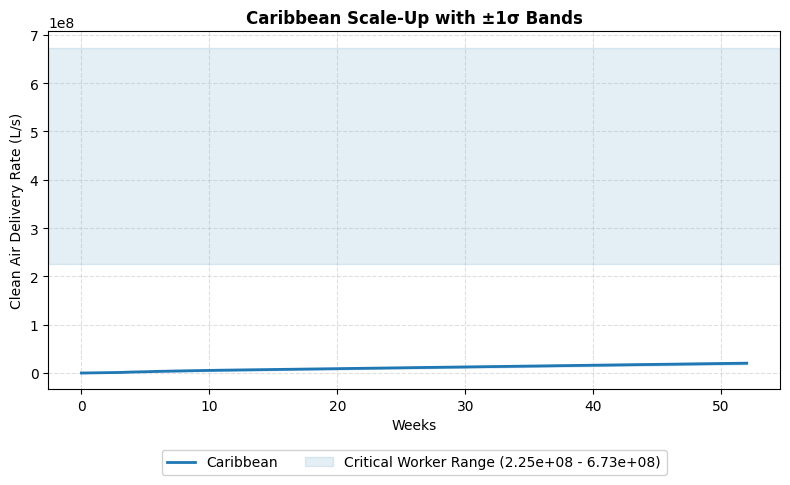

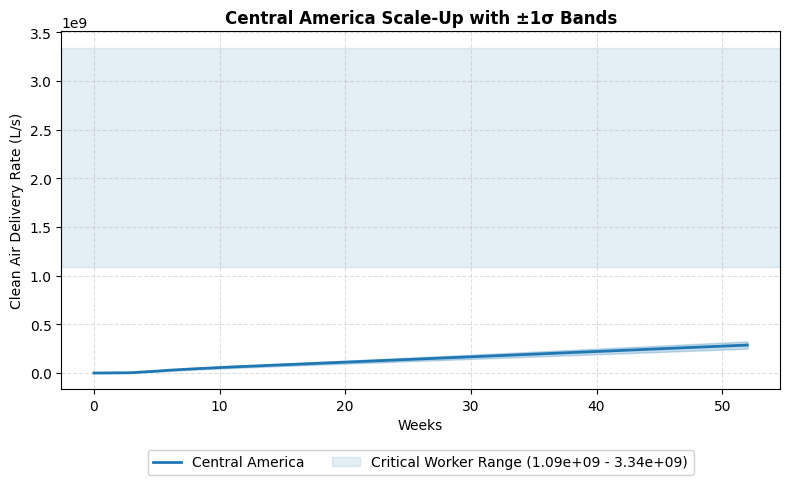

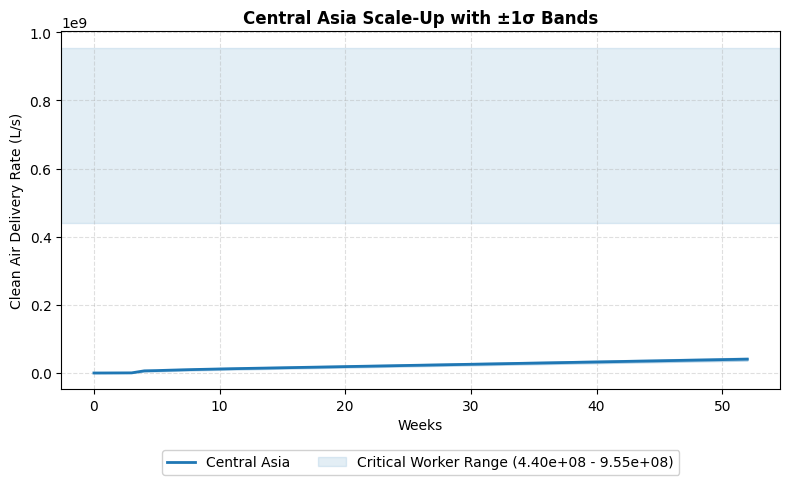

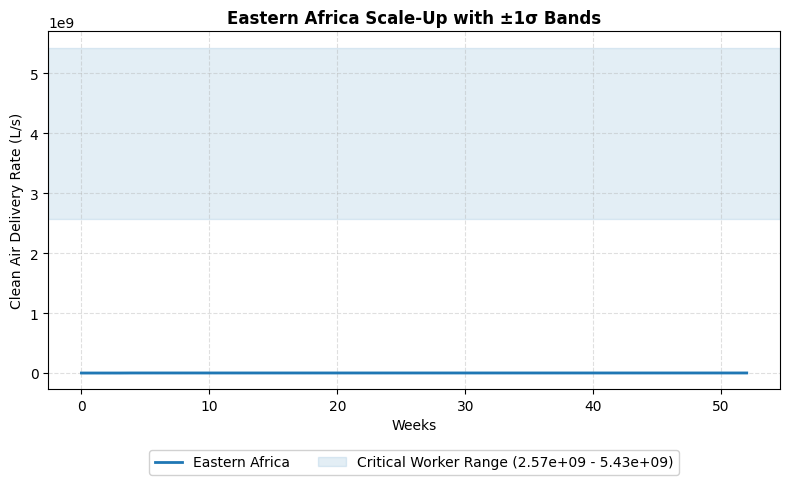

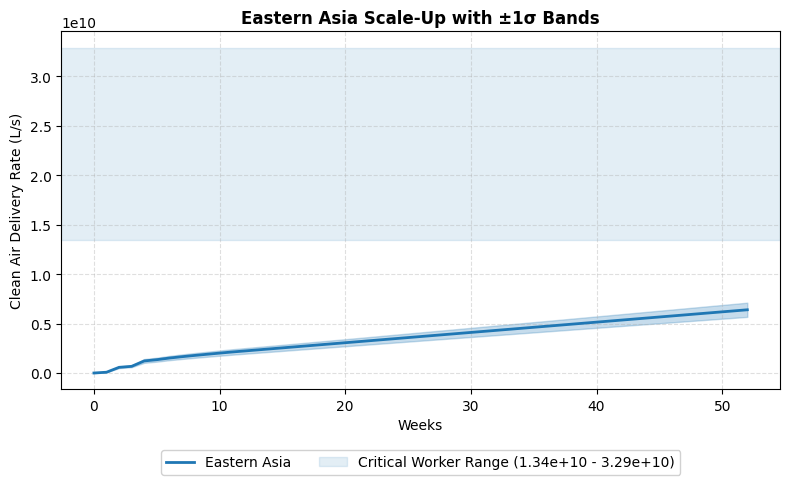

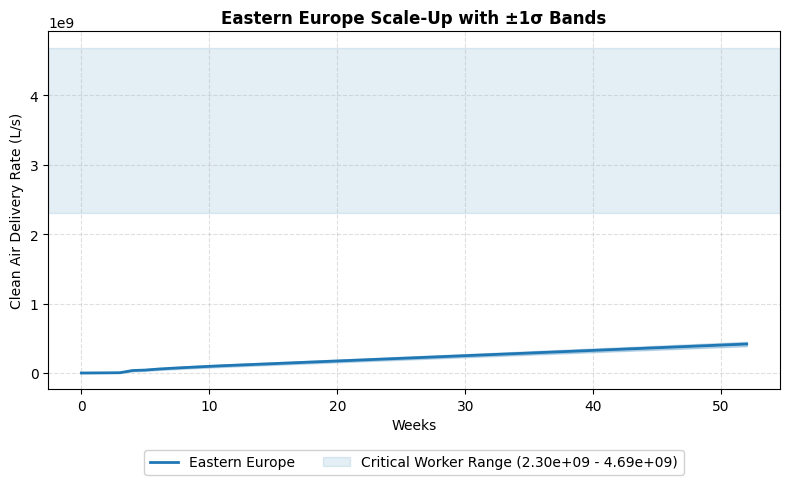

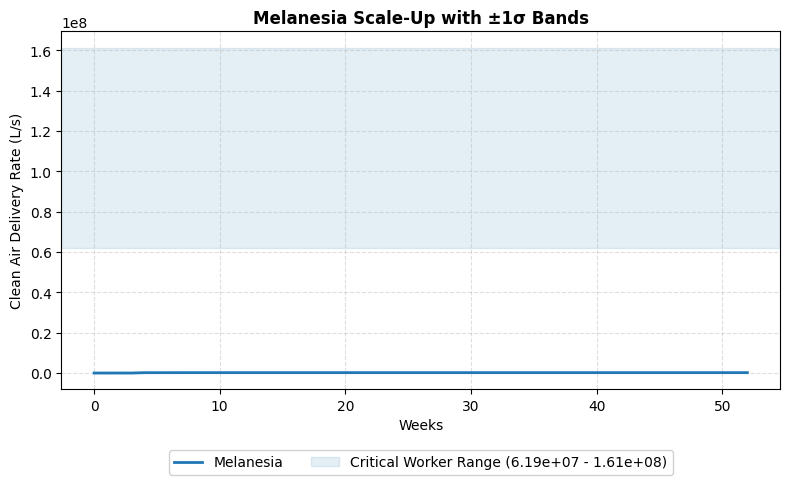

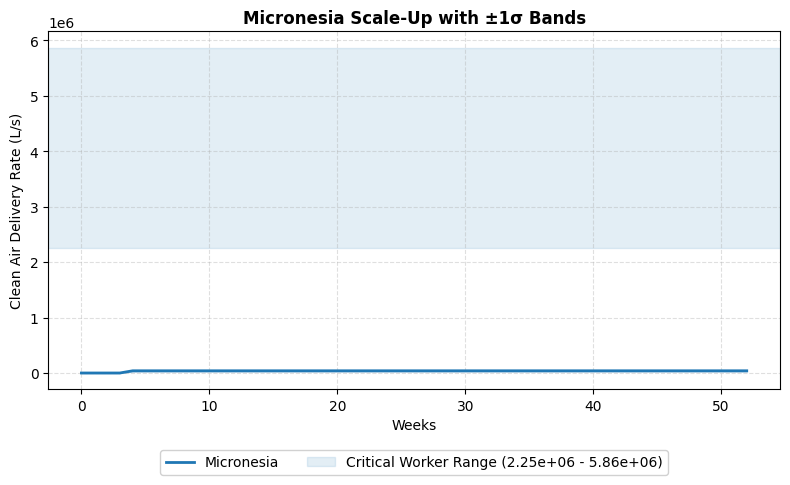

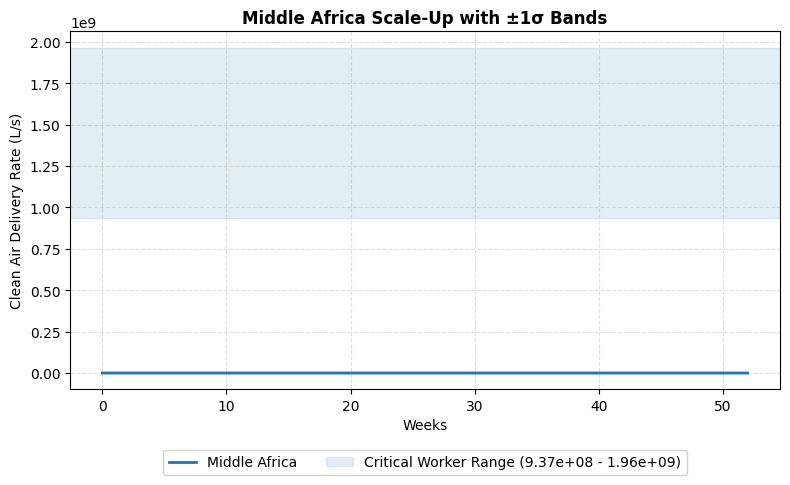

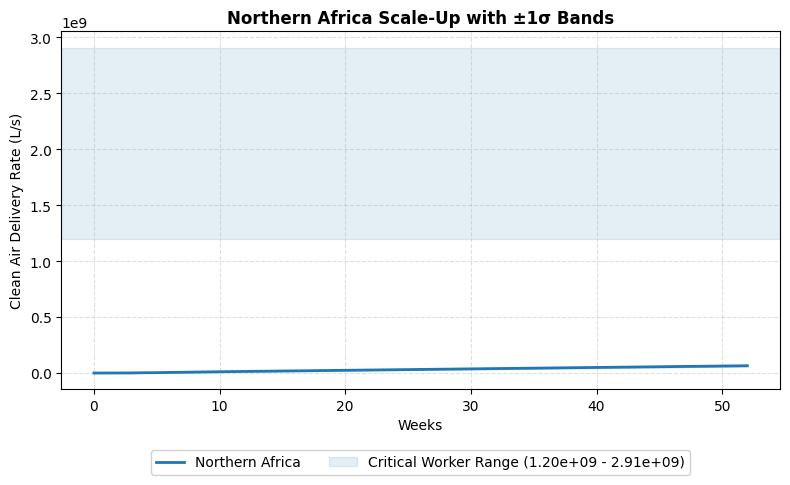

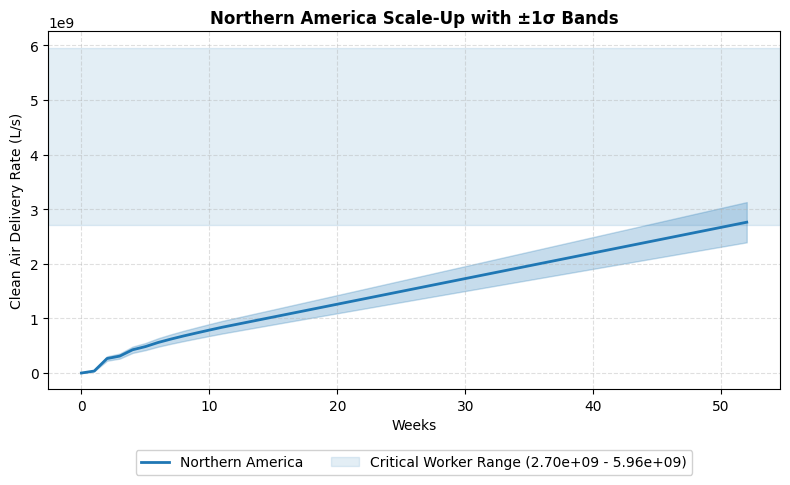

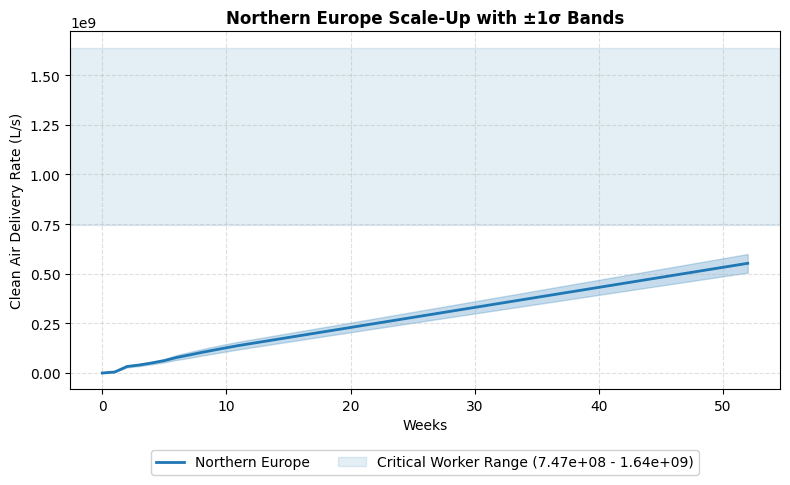

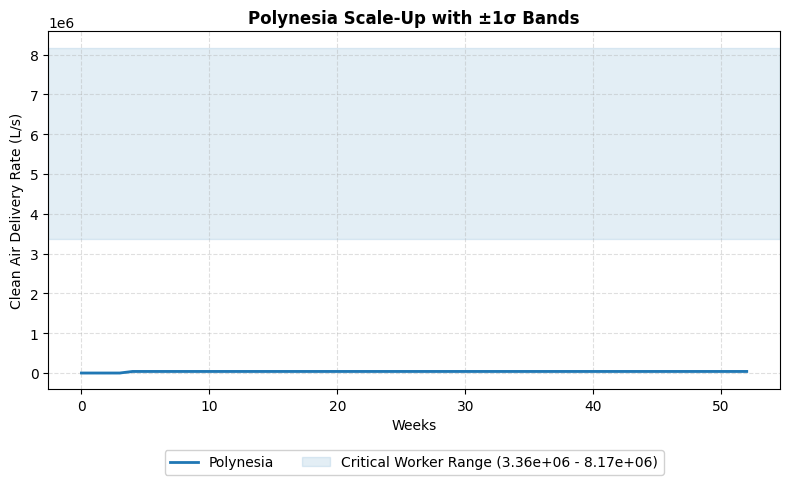

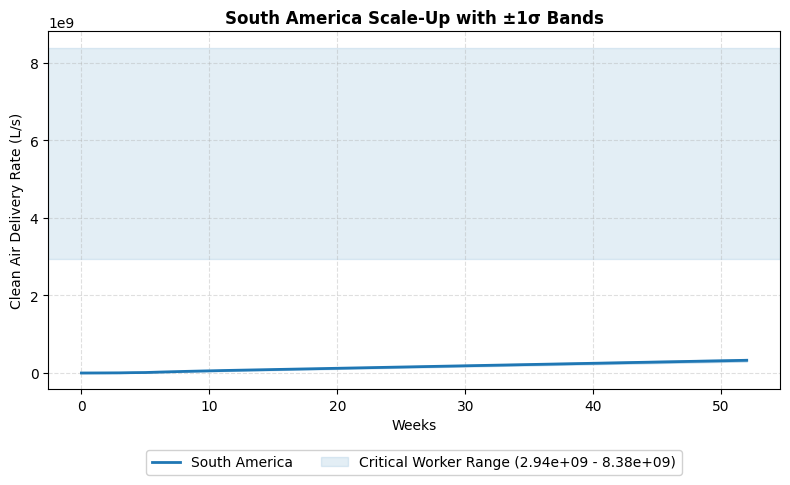

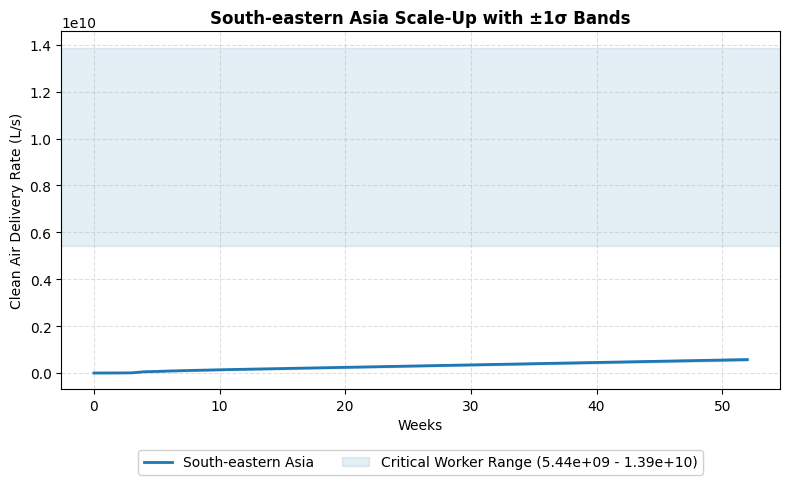

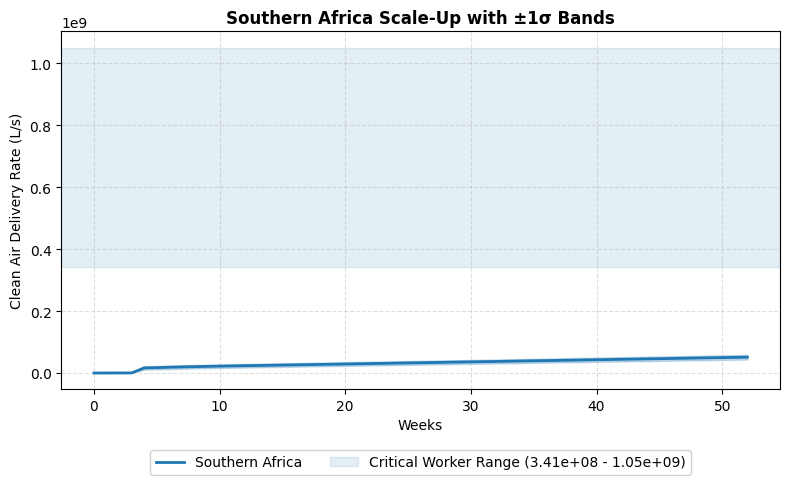

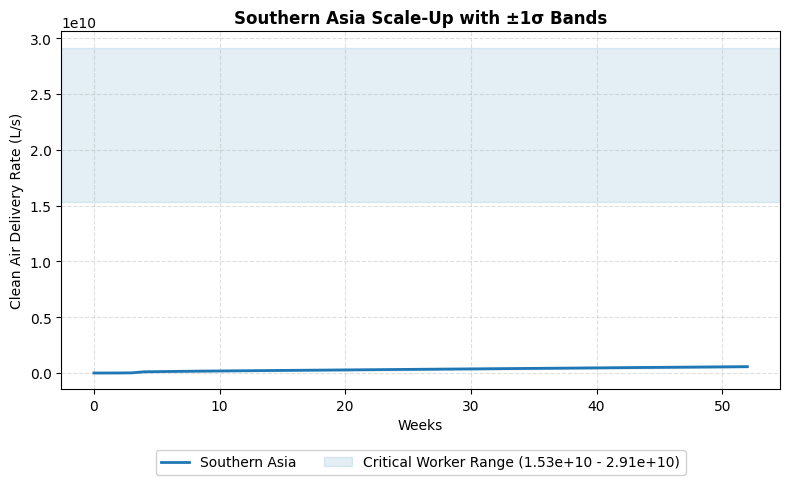

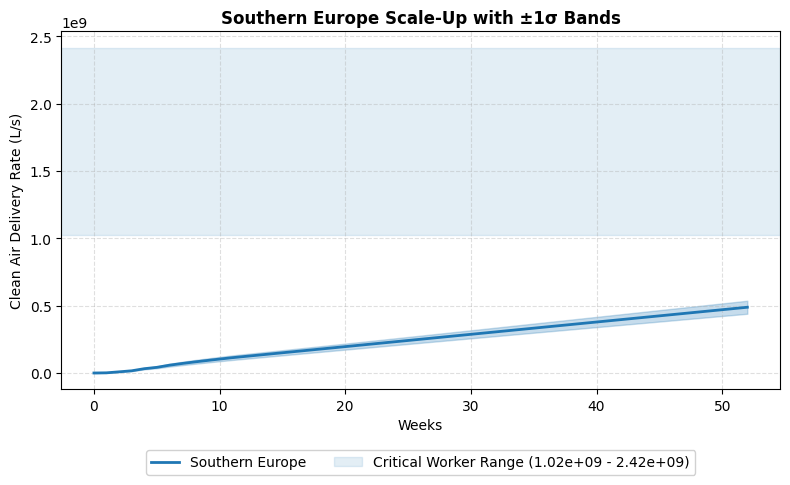

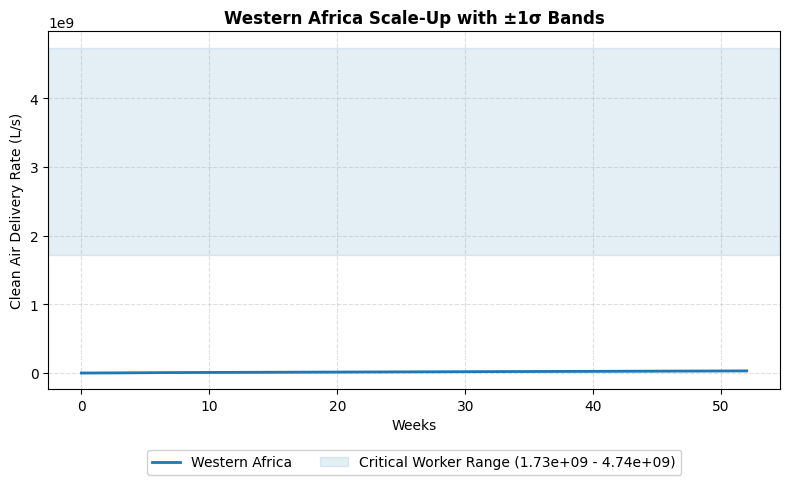

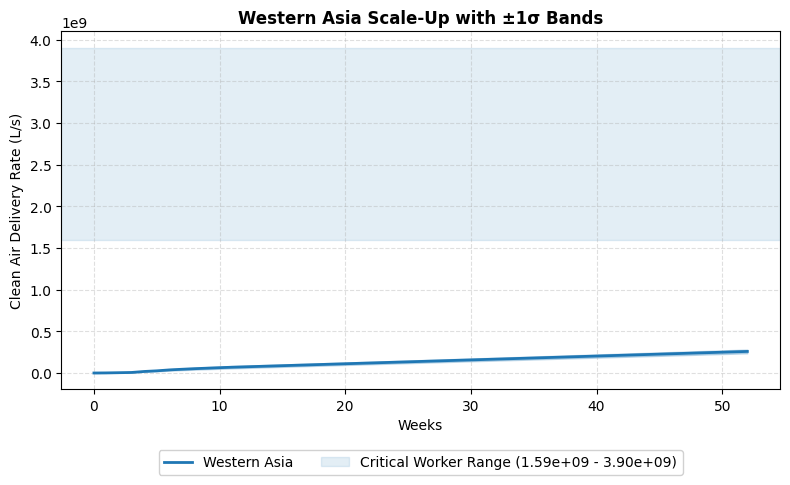

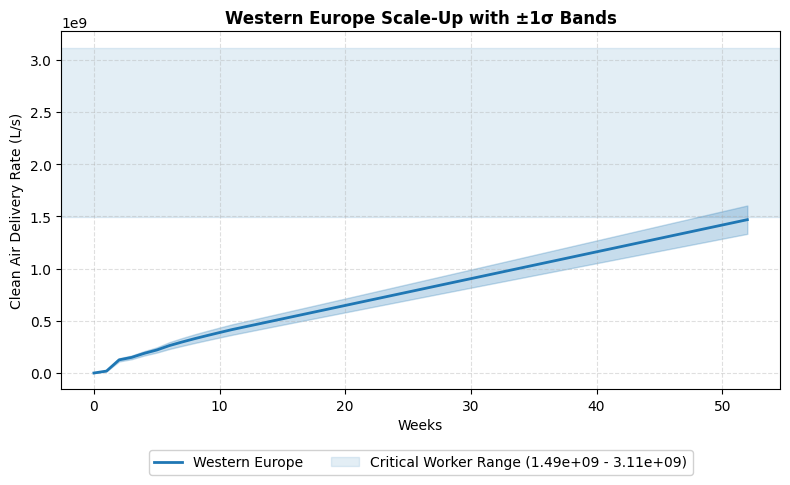

In [37]:
# ---------- All Regions ----------

plot_multiple_regions(df_PERCENT_ECW_LOADED, UNRegion_list, show_CADR=False, percentage=True)

for i in UNRegion_list:
    plot_region(df_MAIN_loaded, i, sigma=1)
    # l,h = get_ECW(df_MAIN_loaded, i)
    # t,v,e = get_series(df_MAIN_loaded, i)
    # print(i,'workers:' ,CADRPP*l)
    # print(i, 'airflow:', round(v[-1]))
    # print(i, 'percent:', round(100*v[-1]/(CADRPP*l)))